In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from GADES.potentials import muller_brown_potential, muller_brown_force, muller_brown_hess

In [2]:
def get_U_plot(x, y):
    xx, yy = np.meshgrid(x, y)
    points = np.column_stack([xx.ravel(), yy.ravel()])
    return muller_brown_potential(points).reshape(xx.shape)

def get_F_plot(x, y):
    xx, yy = np.meshgrid(x, y)
    points = np.column_stack([xx.ravel(), yy.ravel()])
    forces = muller_brown_force(points)  # (N, 2)
    return forces.reshape(*xx.shape, 2)  # (len(y), len(x), 2)

def get_H_plot(x, y):
    xx, yy = np.meshgrid(x, y)
    points = np.column_stack([xx.ravel(), yy.ravel()])
    hessians = muller_brown_hess(points)  # (N, 2, 2)
    return hessians.reshape(*xx.shape, 2, 2)  # (len(y), len(x), 2, 2)

def baoab_langevin_integrator(positions, velocities, forces_u, forces_b,
                               mass, gamma, dt, kBT, force_function_u,
                                 force_function_b, n_steps=1):
    """
    BAOAB Langevin integrator based on Leimkuhler and Matthews (2013).
    https://dx.doi.org/10.1093/amrx/abs010

    Parameters:
        positions (ndarray): Initial positions (shape: [D, ], where D is dimensionality).
        velocities (ndarray): Initial velocities (shape: [D, ]).
        forces_u (ndarray): Initial unbiased forces (shape: [D, ]).
        forces_b (ndarray): Initial biased forces (shape: [D, ]).
        mass (float): Mass of the particles (scalar).
        gamma (float): Friction coefficient. (scalar).
        dt (float): Time step. (scalar).
        n_steps (int): Number of simulation steps. (scalar).
        kBT (float): Thermal energy (\(k_B T\)). (scalar).
        force_function_u (callable): Function to compute unbiased forces given positions (returns forces of shape [D, ]).
        force_function_b (callable): Function to compute biased forces given positions (returns forces of shape [D, ]).

    Returns:
        positions (ndarray): New positions (shape: [D, ]).
        velocities (ndarray): New velocities (shape: [D, ]).
        forces_u (ndarray): Unbiased forces at new position (shape: [D, ]).
        forces_b (ndarray): Biased forces at new position (shape: [D, ]).
    """
    dim = positions.shape[0]

    # Precompute constants
    c1 = np.exp(-gamma * dt)
    c3 = np.sqrt(kBT * (1 - c1**2))
    inv_mass = np.reciprocal(mass)
    inv_mass_sqrt = np.reciprocal(np.sqrt(mass))

    for step in range(n_steps):

        # Step B (First half-step momentum update)
        forces = forces_u + forces_b
        velocities += 0.5 * dt * inv_mass * forces

        # Step A (Half-step position update)
        positions += 0.5 * dt * velocities

        # Step O (Thermostat and randomization)
        random_force = np.random.normal(size=(dim,))
        velocities = c1 * velocities + c3 * inv_mass_sqrt * random_force

        # Step A (Second half-step position update)
        positions += 0.5 * dt * velocities

        # Step B (Second half-step momentum update)
        forces_u = force_function_u(positions)
        forces_b = force_function_b(positions)
        forces = forces_u + forces_b
        velocities += 0.5 * dt * inv_mass * forces

    return positions, velocities, forces_u, forces_b

In [3]:
import matplotlib as mpl

# Global settings for publication-quality plots
mpl.rcParams.update({
    # Fonts
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "mathtext.fontset": "stix",
    "font.size": 9,          # Base font size
    "axes.titlesize": 10,    # Title font size
    "axes.labelsize": 9,     # X/Y label font size
    "xtick.labelsize": 8,    # Tick label font size
    "ytick.labelsize": 8,
    "legend.fontsize": 8,    # Legend font size

    # Line styles
    "lines.linewidth": 1.2,
    "lines.markersize": 4,

    # Axes
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    # Figure
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "figure.figsize": (3.3, 2.5),  # ~1-column figure in most journals
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

In [4]:
# Create a grid of x and y values
x0 = np.linspace(-3.5, 2.0, 30)
x1 = np.linspace(-1.5, 3.5, 30)
X0, X1 = np.meshgrid(x0, x1)

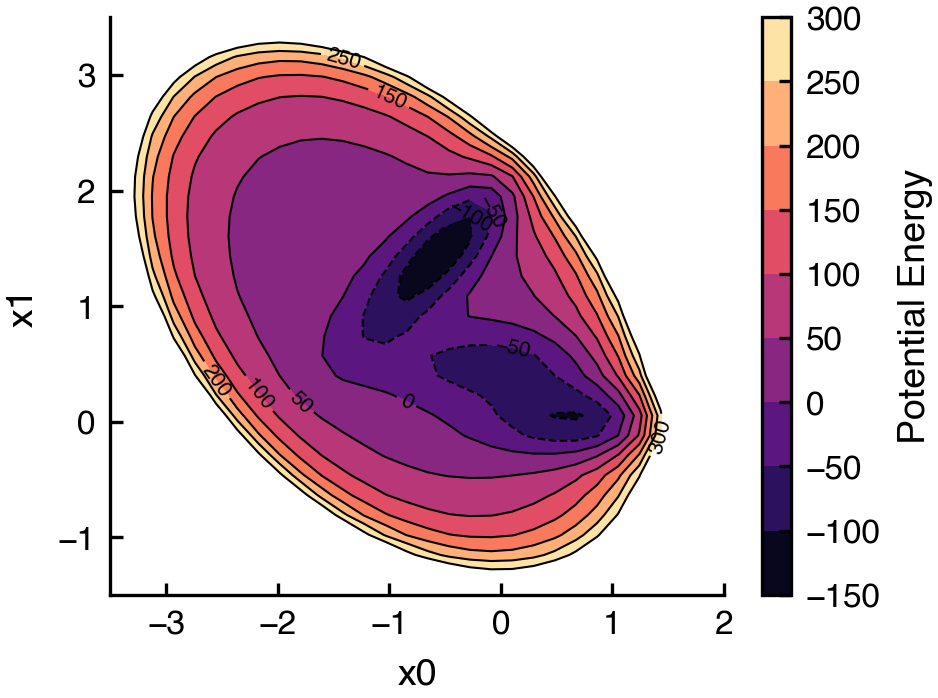

In [5]:
# plotting potential landscape

# Calculate the potential energy at each point
Z = get_U_plot(x0, x1)

# set levels for plotting
countour_levels = np.arange(-150,350,50)

# Create the filled contour plot
plt.contourf(X0, X1, Z, levels=countour_levels, cmap='magma')
plt.colorbar(label='Potential Energy')

# Add contour lines
contour_lines = plt.contour(X0, X1, Z, levels=countour_levels, colors='black', linewidths=0.5)
plt.clabel(contour_lines, inline=True, fontsize=5)

# Add labels and title
plt.xlabel('x0')
plt.ylabel('x1')

# Show the plot
plt.show()

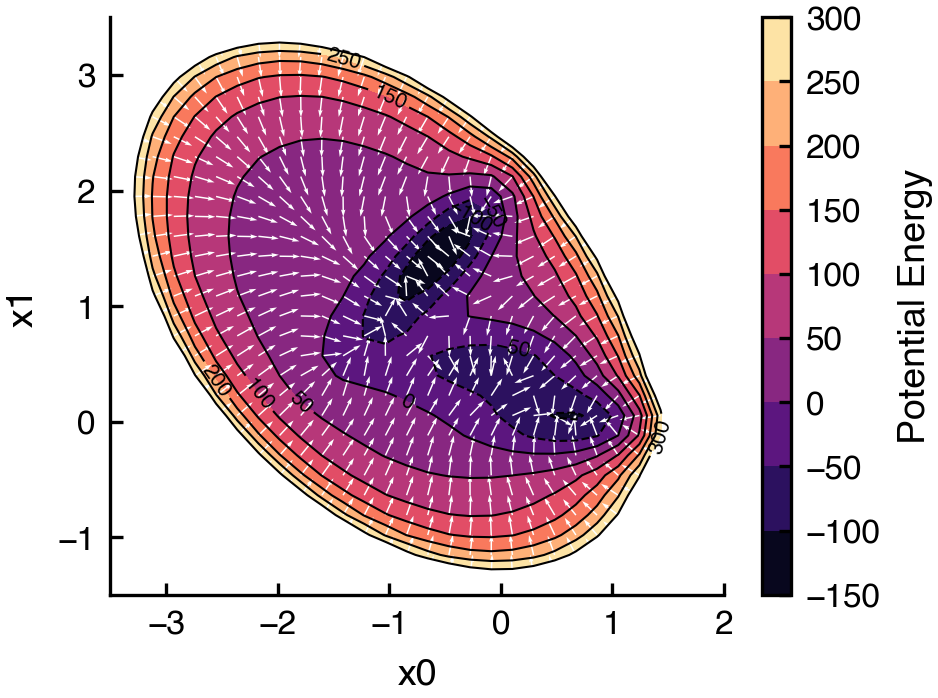

In [6]:
# plotting potential landscape with force field

# computing gradients over the grid
F = get_F_plot(x0, x1)
FX = F[:, :, 0]
FY = F[:, :, 1]

# computing normalized gradient vectors
FXn = FX.copy()
FYn = FY.copy()
norm = np.sqrt(FX**2 + FY**2)
FXn /= norm
FYn /= norm

# Create the filled contour plot
plt.contourf(X0, X1, Z, levels=countour_levels, cmap='magma')
plt.colorbar(label='Potential Energy')

# Add contour lines
contour_lines = plt.contour(X0, X1, Z, levels=countour_levels, colors='black', linewidths=0.5)
plt.clabel(contour_lines, inline=True, fontsize=5)

# Add gradient vectors
plt.quiver(X0, X1, FXn, FYn, color="white", scale=30)

# Add labels and title
plt.xlabel('x0')
plt.ylabel('x1')

# Show the plot
plt.show()

In [7]:
H = get_H_plot(x0,x1)

GX = np.zeros_like(FX)
GY = np.zeros_like(FY)

n = len(x0)
for ii in range(0,n):
  for jj in range(0,n):

    # extracting Hessian at point (ii,jj)
    h = H[ii,jj,:,:]

    # solving for smallest evec by eigh
    w, v = np.linalg.eigh(h)
    w = w[0]
    v = v[:,0]

    # extracting smallest Hessian evec into GX, GY
    GX[ii,jj] = v[0]
    GY[ii,jj] = v[1]

    # aligning gentlest ascent directions with gradient
    s = np.sign(-FX[ii,jj]*GX[ii,jj] - FY[ii,jj]*GY[ii,jj])
    GX[ii,jj] *= s
    GY[ii,jj] *= s

/var/folders/wt/mj85p2nx15lf4smkwmg0fnr80000gn/T/ipykernel_43056/847319894.py:7: RuntimeWarning: invalid value encountered in divide
  GXn /= norm
/var/folders/wt/mj85p2nx15lf4smkwmg0fnr80000gn/T/ipykernel_43056/847319894.py:8: RuntimeWarning: invalid value encountered in divide
  GYn /= norm


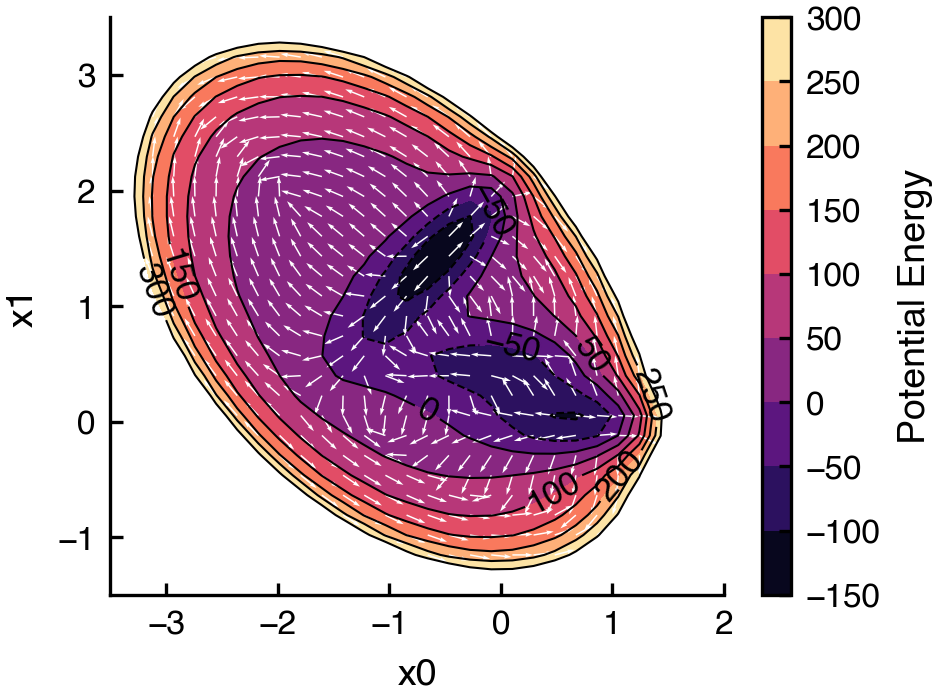

In [8]:
# plotting potential landscape with gentlest ascent field

# normalizing gentlest ascent directions
GXn = GX.copy()
GYn = GY.copy()
norm = np.sqrt(GXn**2 + GYn**2)
GXn /= norm
GYn /= norm

# Create the filled contour plot
plt.contourf(X0, X1, Z, levels=countour_levels, cmap='magma')
plt.colorbar(label='Potential Energy')

# Add contour lines
contour_lines = plt.contour(X0, X1, Z, levels=countour_levels, colors='black', linewidths=0.5)
plt.clabel(contour_lines, inline=True, fontsize=8)

# Add gradient vectors
plt.quiver(X0, X1, GXn, GYn, color="white", scale=30)

# Add labels and title
plt.xlabel('x0')
plt.ylabel('x1')

# Show the plot
plt.show()

In [9]:
# Parameters
x = np.array([-0.5582, 1.4417])
v = np.zeros_like(x)
f = muller_brown_force(x)
fb = np.zeros_like(x)
mass = 1.0
gamma = 1.0
dt = 0.01
n_steps = 1_000_000
kBT = 2.0  # Thermal energy

In [10]:
# prepare storage arrays
traj_p = np.full((n_steps+1, x.shape[0]), np.nan)
traj_v = np.full((n_steps+1, x.shape[0]), np.nan)
traj_fu = np.full((n_steps+1, x.shape[0]), np.nan)
traj_fb = np.full((n_steps+1, x.shape[0]), np.nan)

traj_p[0,:] = x
traj_v[0,:] = v
traj_fu[0,:] = f
traj_fb[0,:] = fb

In [11]:
# Run the integrator
for i in tqdm(range(1,n_steps+1)):

  x, v, f, fb = baoab_langevin_integrator(
    x, v, f, fb, mass, gamma, dt, kBT, muller_brown_force, np.zeros_like
  )

  traj_p[i,:] = x
  traj_v[i,:] = v
  traj_fu[i,:] = f
  traj_fb[i,:] = fb

# Convert trajectory to numpy array for analysis
traj_p = np.array(traj_p)
traj_v = np.array(traj_v)
traj_fu = np.array(traj_fu)
traj_fb = np.array(traj_fb)

  0%|          | 0/1000000 [00:00<?, ?it/s]

In [ ]:
np.save("muller_brown_unbiased_1e6.npy", traj_p)

In [ ]:
traj_p = np.load("muller_brown_unbiased_1e6.npy")

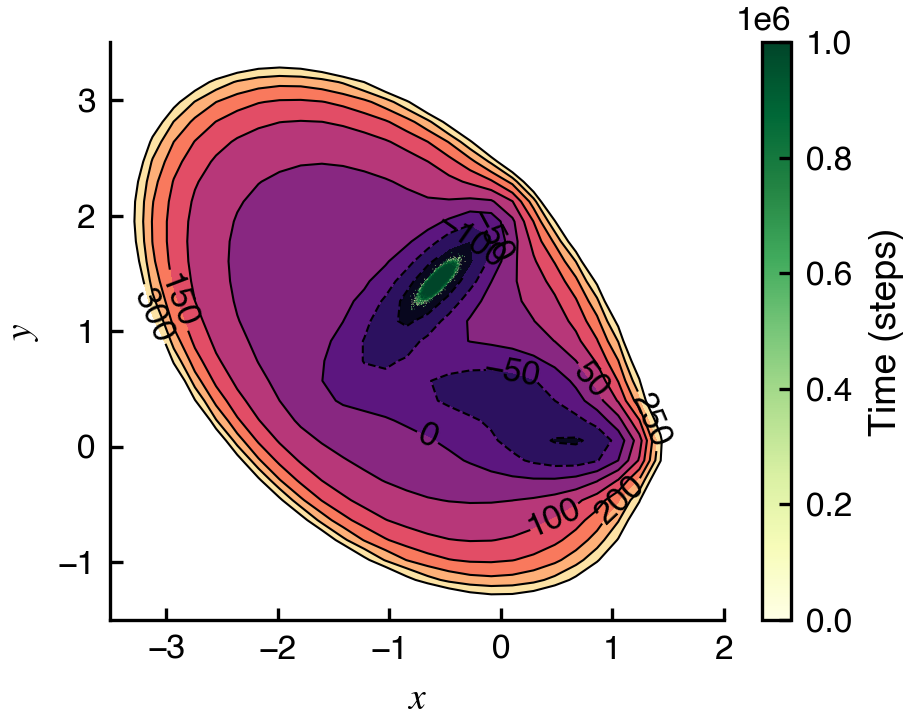

In [14]:
# Plotting trajectory over potential landscape

# set levels for plotting
countour_levels = np.arange(-150,350,50)

# Create the filled contour plot
plt.contourf(x0, x1, Z, levels=countour_levels, cmap='magma')

# Add contour lines
contour_lines = plt.contour(x0, x1, Z, levels=countour_levels, colors='black', linewidths=0.5)
plt.clabel(contour_lines, inline=True, fontsize=8)

# Add trajectory
x = traj_p[::5,0]
y = traj_p[::5,1]
time = np.arange(traj_p.shape[0])[::5]
scatter = plt.scatter(x, y, c=time, cmap='YlGn', marker='o', 
                      s=0.01, linewidths=0.1, label='Trajectory', zorder=10)  # Color by time
plt.colorbar(scatter, label='Time (steps)')

# Add labels and title
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')

# Show the plot
plt.show()

In [15]:
def muller_brown_gad_force(position: np.ndarray, kappa: float = 0.9) -> np.ndarray:
    position = np.atleast_2d(position)
    N = position.shape[0]

    forces_u = np.atleast_2d(muller_brown_force(position))
    hessians = np.atleast_3d(muller_brown_hess(position))
    if hessians.shape == (2, 2, 1):
        hessians = hessians[:, :, 0][np.newaxis] # (1, 2, 2)

    results = np.zeros((N, 2))
    for i in range(N):
        w, v = np.linalg.eigh(hessians[i])
        n = v[:, 0]
        n = n / np.linalg.norm(n)

        forces_b = -np.dot(forces_u[i], n) * n * kappa

        magnitude = np.linalg.norm(forces_b)
        scale = 1.0#min(1.0, 10000.0 / magnitude) if magnitude > 0 else 1.0
        results[i] = forces_b * scale

    return results[0] if N == 1 else results

In [16]:
# Parameters
x = np.array([-1.0, 1.0])
v = np.zeros_like(x)
f = muller_brown_force(x)
fb = muller_brown_gad_force(x, kappa=0.9)
mass = 1.0
gamma = 1.0
dt = 0.01
n_steps = 1_000_000
kBT = 2.0  # Thermal energy

In [17]:
# prepare storage arrays
traj_p = np.full((n_steps+1, x.shape[0]), np.nan)
traj_v = np.full((n_steps+1, x.shape[0]), np.nan)
traj_fu = np.full((n_steps+1, x.shape[0]), np.nan)
traj_fb = np.full((n_steps+1, x.shape[0]), np.nan)

traj_p[0,:] = x
traj_v[0,:] = v
traj_fu[0,:] = f
traj_fb[0,:] = fb

In [18]:
# Run the integrator
for i in tqdm(range(1,n_steps+1)):

  x, v, f, fb = baoab_langevin_integrator(
    x, v, f, fb, mass, gamma, dt, kBT, muller_brown_force, muller_brown_gad_force
  )

  traj_p[i,:] = x
  traj_v[i,:] = v
  traj_fu[i,:] = f
  traj_fb[i,:] = fb

# Convert trajectory to numpy array for analysis
traj_p = np.array(traj_p)
traj_v = np.array(traj_v)
traj_fu = np.array(traj_fu)
traj_fb = np.array(traj_fb)

  0%|          | 0/1000000 [00:00<?, ?it/s]

In [ ]:
np.save("muller_brown_GADES_1e6_clamped.npy", traj_p)

In [ ]:
traj_p = np.load("muller_brown_GADES_1e6_clamped.npy")

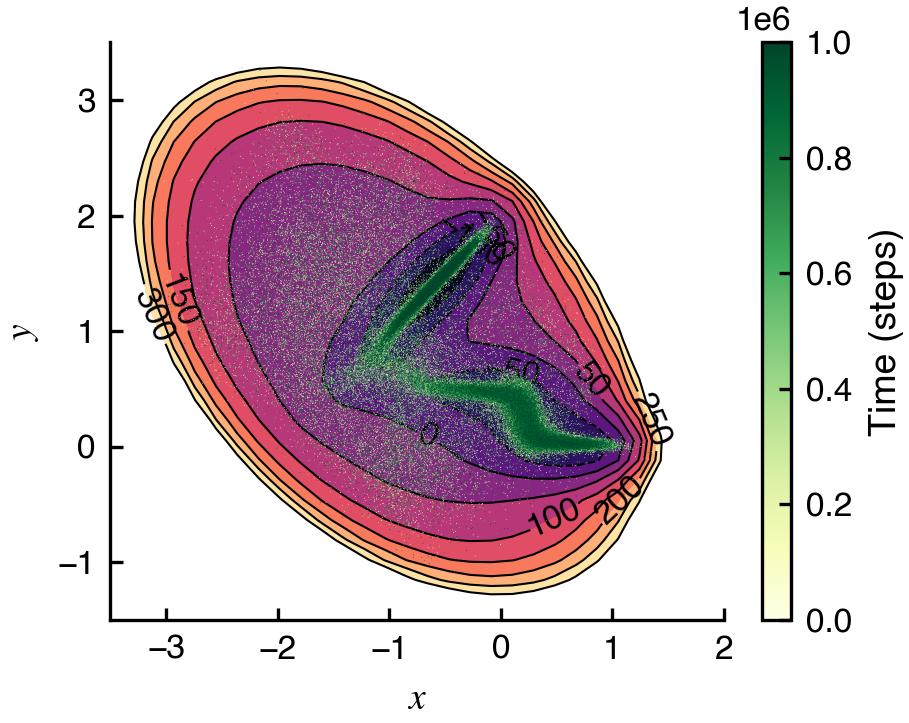

In [21]:
# Plotting trajectory over potential landscape

# set levels for plotting
countour_levels = np.arange(-150,350,50)

# Create the filled contour plot
plt.contourf(x0, x1, Z, levels=countour_levels, cmap='magma')

# Add contour lines
contour_lines = plt.contour(x0, x1, Z, levels=countour_levels, colors='black', linewidths=0.5)
plt.clabel(contour_lines, inline=True, fontsize=8)

# Add trajectory
x = traj_p[::5,0]
y = traj_p[::5,1]
time = np.arange(traj_p.shape[0])[::5]
scatter = plt.scatter(x, y, c=time, cmap='YlGn', marker='o', 
                      s=0.01, linewidths=0.1, label='Trajectory', zorder=10)  # Color by time
plt.colorbar(scatter, label='Time (steps)')

# Add labels and title
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')

# Show the plot
plt.show()